# El corazón ya avisa. El examen estándar no sabe leerlo.

Cada año, miles de personas mueren de un paro cardíaco que un desfibrilador habría cortado. El cuello de botella no es la máquina: es saber **a quién** ponérsela. El examen que usan los médicos hoy —la fracción de eyección (FEVI), qué tan fuerte bombea el corazón— se le escapa a la mayoría.

Un equipo le puso deep learning a **441.614 electrocardiogramas** de una región de Suecia, cruzados con certificados de defunción. El modelo encontró en la onda del ECG una señal que **nadie había descrito** — y que ordena el riesgo mucho mejor que el estándar actual.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** [An ECG biomarker for sudden cardiac death discovered with deep learning](https://doi.org/10.1038/s41586-026-10674-6) · *Nature (2026)*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-01-biomarcador-ecg-muerte-subita/notebook.ipynb)

🎬 **Video:** _Pendiente_

## Qué midieron

La **muerte súbita cardíaca** (MSC) es, en teoría, evitable: un desfibrilador implantable (DAI) puede cortar la arritmia mortal antes de que mate. El problema es predecir a quién le va a pasar. El único biomarcador de uso amplio —la **FEVI**— tiene dos fallas: se le escapan la mayoría de las muertes súbitas, y a la vez marca a muchos pacientes de bajo riesgo para desfibriladores que nunca llegan a activarse.

El equipo entrenó un modelo de deep learning sobre **todos los ECG de una región sueca (Halland, 2010–2016)** ligados a certificados de defunción, y lo evaluó en un *lockbox* que el modelo nunca vio durante el entrenamiento. Después lo puso a prueba, **sin reentrenar** (*zero-shot*), en un sistema de salud de EE.UU. y en un registro hospitalario de Taiwán.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
AUC_AZAR = 0.5          # Una moneda al aire ordena el riesgo con AUC 0,5
AUC_PERFECTO = 1.0      # Un oráculo perfecto: 1,0
COLOR_DATOS = '#2563EB'      # Modelo ECG (deep learning)
COLOR_ALERTA = '#DC2626'     # Control / línea de azar
COLOR_REFERENCIA = '#D97706' # Estándar actual (FEVI)
COLOR_CONTEXTO = '#BBBBBB'   # Comparadores previos
FUENTE = 'Fuente: Schubert et al. (2026), Nature | Datos: valores del texto Open Access del paper'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local en el repo → fallback a GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los tres bloques de datos (valores reportados en el paper)
disc = pd.read_csv('datos/discriminacion_mcs.csv')
gen = pd.read_csv('datos/generalizacion_cohortes.csv')
estr = pd.read_csv('datos/estratificacion_riesgo.csv')

print('── Discriminación de muerte súbita (Suecia, lockbox 40%) ──')
print(disc.to_string(index=False))
print('\n── Generalización zero-shot (sin reentrenar) ──')
print(gen.to_string(index=False))
print('\n── Estratificación de riesgo ──')
print(estr.to_string(index=False))

── Discriminación de muerte súbita (Suecia, lockbox 40%) ──
                       metodo   auc  ci_low  ci_high                 tipo
   Modelo ECG (deep learning) 0.872   0.843    0.899           este_paper
    Puntaje AHA/ACC (10 años) 0.697     NaN      NaN   comparador_clinico
Modelo ECG-SEER (cardiopatía) 0.655     NaN      NaN comparador_dl_previo

── Generalización zero-shot (sin reentrenar) ──
                       cohorte   pais          tarea    n_ecg   auc  ci_low  ci_high
              Sharp HealthCare EE.UU.          VF/VT 251858.0 0.822   0.812    0.831
                   Nightingale Taiwán paro arrítmico   4268.0 0.767   0.706    0.823
                Región Halland Suecia          VF/VT 113072.0 0.717   0.676    0.756
Control placebo (no-arrítmico) Suecia   no-arrítmico      NaN 0.582   0.529    0.636

── Estratificación de riesgo ──
                          grupo  pct_muestra  tasa_anual_mcs_pct  no_solapa_lvef_pct
       Alto riesgo (modelo ECG)          2.2        

## Aquí está.

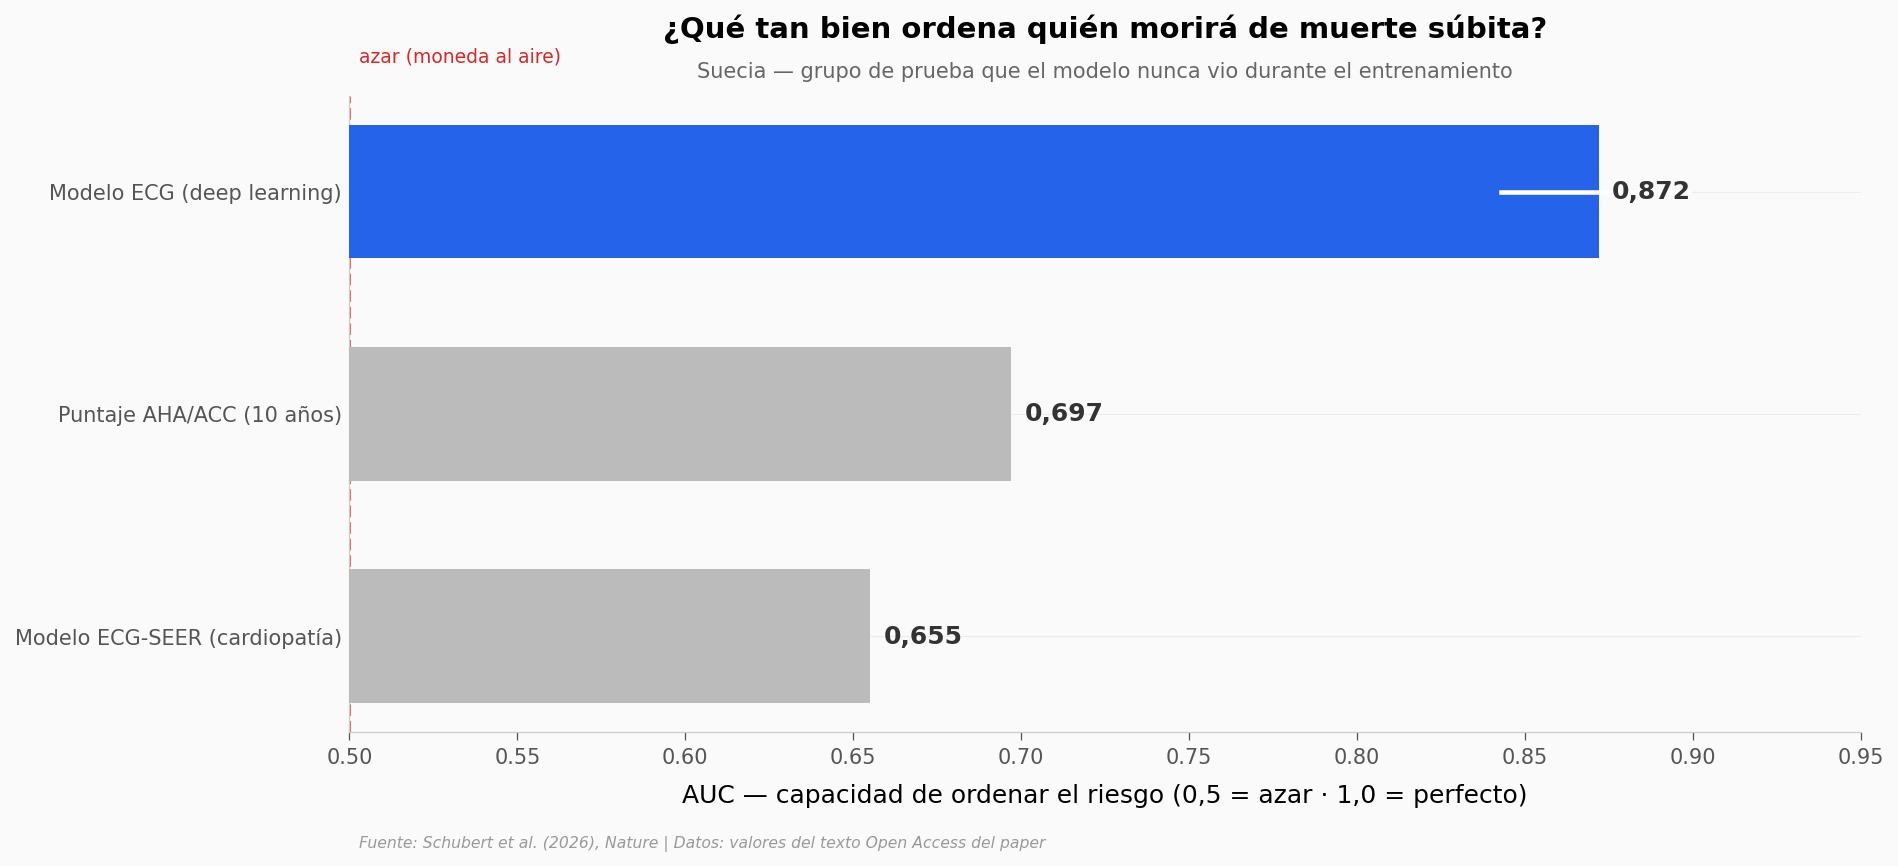

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))
d = disc.sort_values('auc').reset_index(drop=True)
colors = [COLOR_DATOS if t == 'este_paper' else COLOR_CONTEXTO for t in d['tipo']]
y = np.arange(len(d))
ax.barh(y, d['auc'], color=colors, height=0.6, zorder=3)

for i, row in d.iterrows():
    # Intervalo de confianza (solo el modelo ECG lo reporta)
    if not np.isnan(row['ci_low']):
        ax.plot([row['ci_low'], row['ci_high']], [i, i], color='white', lw=2.2, zorder=6)
    ax.text(row['auc'] + 0.004, i, f"{row['auc']:.3f}".replace('.', ','),
            va='center', ha='left', color='#333333', fontweight='bold', fontsize=12, zorder=6)

ax.axvline(AUC_AZAR, color=COLOR_ALERTA, lw=1.5, ls='--', alpha=0.7)
ax.text(AUC_AZAR + 0.003, len(d) - 0.35, 'azar (moneda al aire)',
        color=COLOR_ALERTA, fontsize=9, va='top')

ax.set_yticks(y)
ax.set_yticklabels(d['metodo'], fontsize=10)
ax.set_xlim(0.5, 0.95)
ax.set_xlabel('AUC — capacidad de ordenar el riesgo (0,5 = azar · 1,0 = perfecto)')
ax.set_title('¿Qué tan bien ordena quién morirá de muerte súbita?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Suecia — grupo de prueba que el modelo nunca vio durante el entrenamiento',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/discriminacion.png', dpi=200, bbox_inches='tight')
plt.show()

El modelo ordena el riesgo con un **AUC de 0,87**. El puntaje clínico que se usa hoy (AHA/ACC) se queda en **0,70**, y un modelo de deep learning anterior, en **0,66**.

Traducido: si tomas al azar a una persona que morirá de muerte súbita y a otra que no, el modelo le da mayor riesgo a la primera **87 de cada 100 veces**. No es un diagnóstico —nadie tiene bola de cristal—, es un termómetro de riesgo. Pero como termómetro, la distancia con el estándar actual es enorme.

## ¿Y fuera de Suecia?

Un modelo entrenado en un solo país puede estar aprendiendo manías locales: el equipo del hospital, la población, hasta la forma de archivar los ECG. La prueba de fuego es soltarlo **sin reentrenar** en otros continentes y ver si aguanta.

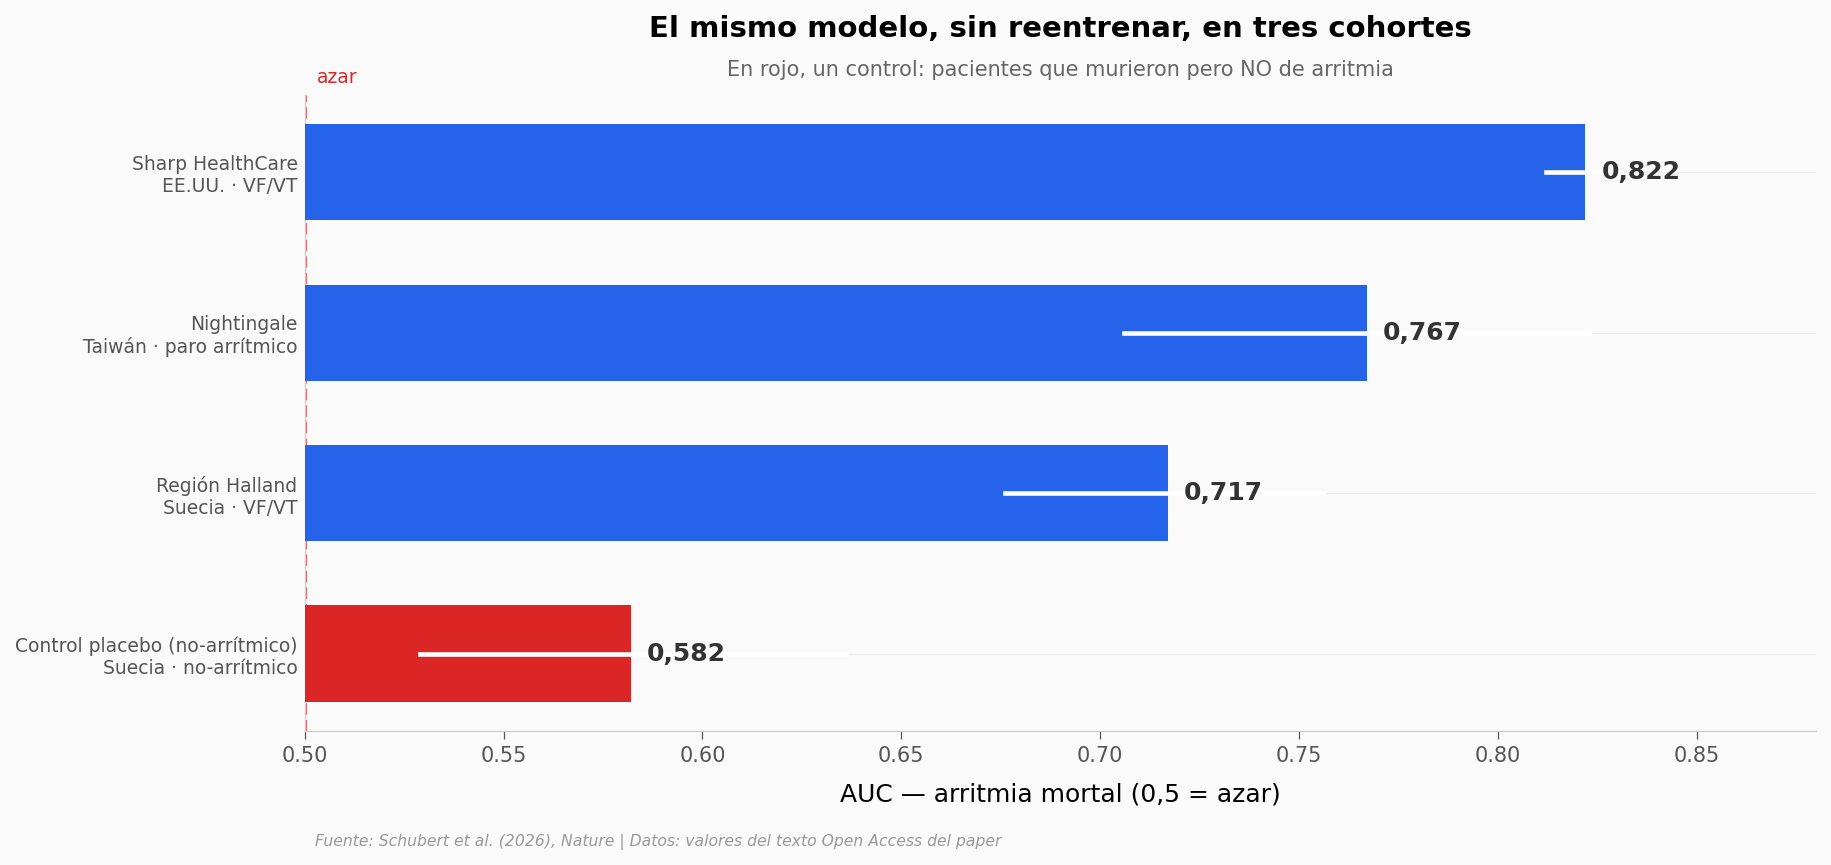

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))
g = gen.sort_values('auc').reset_index(drop=True)
es_control = g['cohorte'].str.contains('placebo', case=False)
colors = [COLOR_ALERTA if c else COLOR_DATOS for c in es_control]
y = np.arange(len(g))
ax.barh(y, g['auc'], color=colors, height=0.6, zorder=3)

for i, row in g.iterrows():
    if not np.isnan(row['ci_low']):
        ax.plot([row['ci_low'], row['ci_high']], [i, i], color='white', lw=2.2, zorder=6)
    ax.text(row['auc'] + 0.004, i, f"{row['auc']:.3f}".replace('.', ','),
            va='center', ha='left', color='#333333', fontweight='bold', fontsize=12, zorder=6)

ax.axvline(AUC_AZAR, color=COLOR_ALERTA, lw=1.5, ls='--', alpha=0.7)
ax.text(AUC_AZAR + 0.003, len(g) - 0.35, 'azar', color=COLOR_ALERTA, fontsize=9, va='top')

etiquetas = [f"{c}\n{p} · {t}" for c, p, t in zip(g['cohorte'], g['pais'], g['tarea'])]
ax.set_yticks(y)
ax.set_yticklabels(etiquetas, fontsize=9)
ax.set_xlim(0.5, 0.88)
ax.set_xlabel('AUC — arritmia mortal (0,5 = azar)')
ax.set_title('El mismo modelo, sin reentrenar, en tres cohortes', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'En rojo, un control: pacientes que murieron pero NO de arritmia',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/generalizacion.png', dpi=200, bbox_inches='tight')
plt.show()

El control es la pieza que da confianza. Son pacientes que **sí** murieron, pero **no** de una arritmia. Ahí el modelo cae a **0,58** — casi una moneda al aire. Justo lo que uno quiere ver: el modelo no está oliendo "muerte" en general, está detectando el patrón eléctrico específico que antecede a un paro arrítmico.

Y aguanta el viaje: **AUC 0,82 en EE.UU. (251.858 ECG)** y **0,77 en Taiwán (4.268 pacientes)**, sin haber visto un solo dato de esas poblaciones durante el entrenamiento.

Queda la pregunta que importa en la clínica: ¿a quién señala este modelo que el estándar actual no ve?

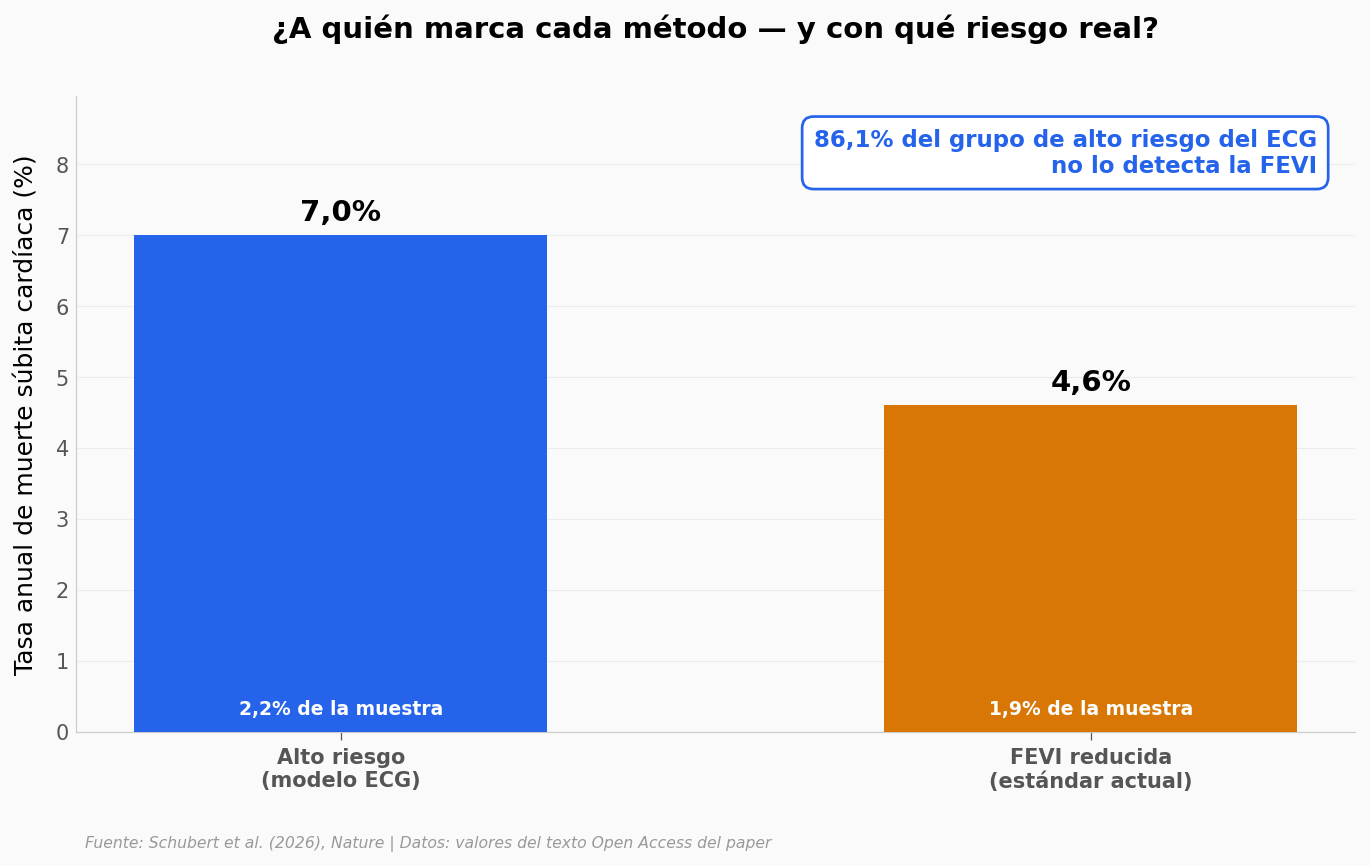

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))
grupos = ['Alto riesgo\n(modelo ECG)', 'FEVI reducida\n(estándar actual)']
tasas = estr['tasa_anual_mcs_pct'].tolist()
pcts = estr['pct_muestra'].tolist()
colors = [COLOR_DATOS, COLOR_REFERENCIA]
x = np.arange(len(grupos))
ax.bar(x, tasas, color=colors, width=0.55, zorder=3)

for i, (t, p) in enumerate(zip(tasas, pcts)):
    ax.text(i, t + 0.12, f"{t:.1f}%".replace('.', ','),
            ha='center', va='bottom', fontweight='bold', fontsize=14)
    ax.text(i, 0.18, f"{p:.1f}% de la muestra".replace('.', ','),
            ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(grupos, fontsize=10, fontweight='bold')
ax.set_ylabel('Tasa anual de muerte súbita cardíaca (%)')
ax.set_ylim(0, max(tasas) * 1.28)
ax.set_title('¿A quién marca cada método — y con qué riesgo real?',
             fontsize=14, fontweight='bold', pad=28)

# El dato que lo cambia todo: el solapamiento
no_solapa = estr['no_solapa_lvef_pct'].dropna().iloc[0]
ax.text(0.97, 0.95, f'{no_solapa:.1f}% del grupo de alto riesgo del ECG\nno lo detecta la FEVI'.replace('.', ','),
        transform=ax.transAxes, ha='right', va='top', fontsize=11, fontweight='bold',
        color=COLOR_DATOS, bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=COLOR_DATOS, lw=1.3))
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/estratificacion.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y detectarlos sirve de algo?

Encontrar pacientes de riesgo solo importa si actuar cambia el desenlace. Entre los pacientes de alto riesgo del ECG a los que **sí** se les implantó un desfibrilador, la mortalidad fue **54,4% menor de lo esperado**.

Aquí toca frenar. Ese número **sugiere** un beneficio, no lo prueba: nadie repartió los desfibriladores al azar —esto no es un ensayo clínico—, y los propios autores advierten que factores no medidos pueden sesgar cualquier estimación de causa. Es una señal fuerte para **diseñar** el ensayo, no la conclusión del ensayo. Lo mismo con el mecanismo del biomarcador: el equipo formula y prueba de forma **preliminar** una hipótesis nueva sobre por qué ocurre la muerte súbita. Es una pregunta abierta, no un veredicto.

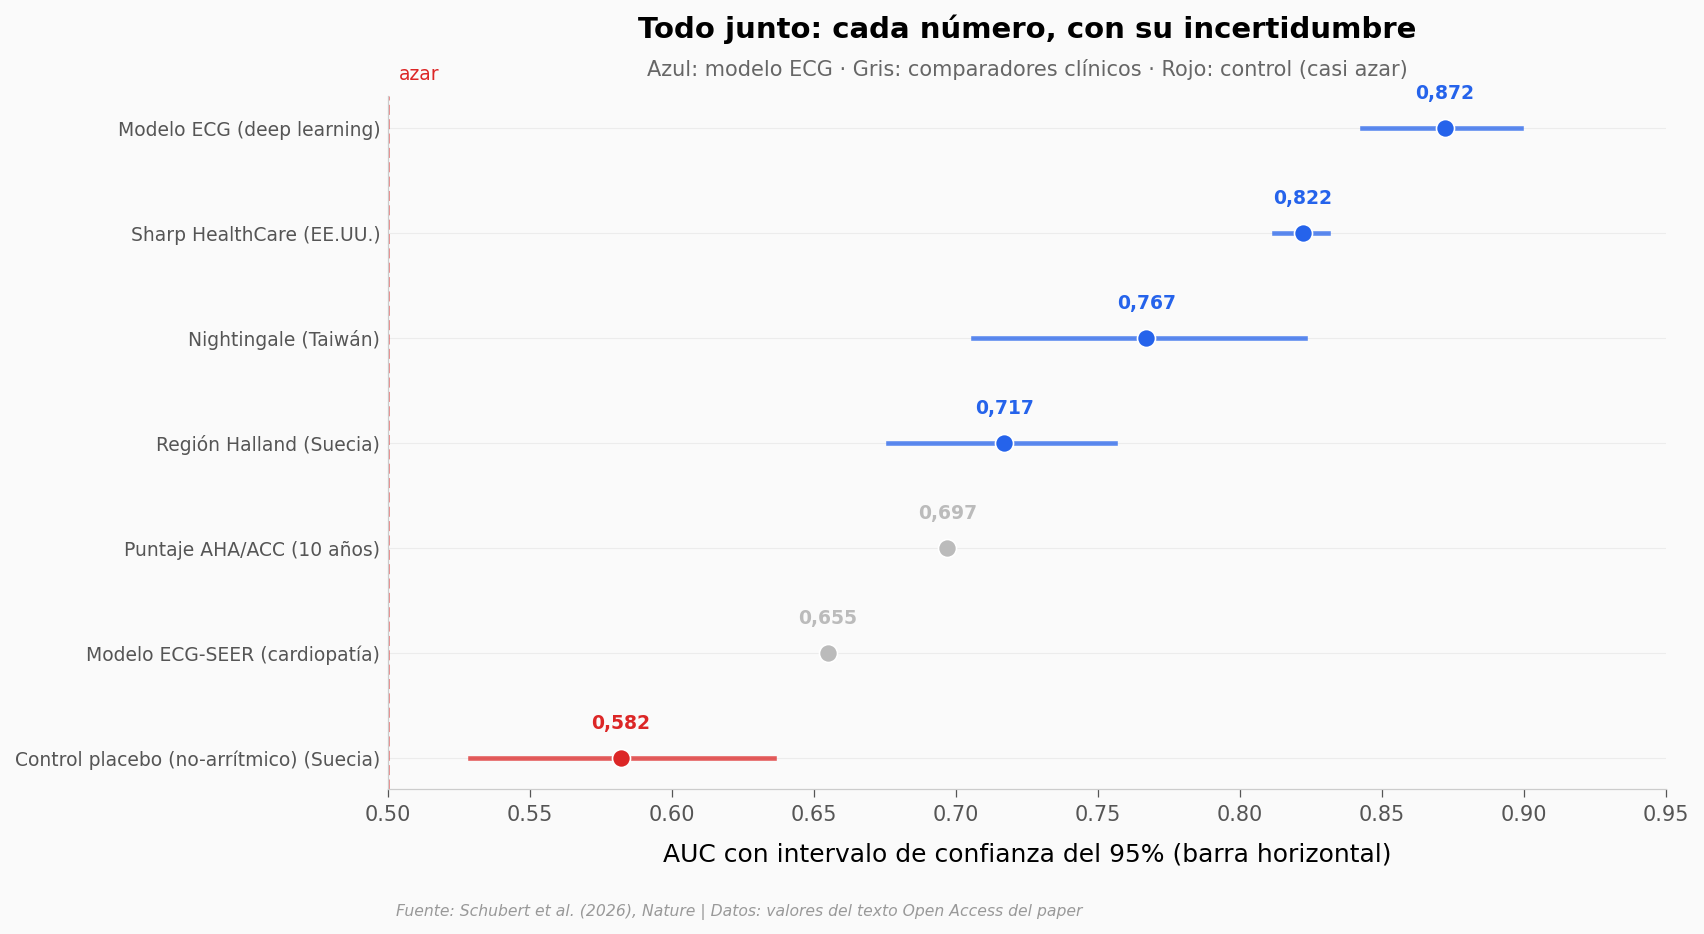

In [5]:
# Regla 6 (excepción benchmark): sin distribución natural que histogramar,
# el cierre cuantitativo es un forest plot que junta cada AUC con su incertidumbre.
filas = []
for _, r in disc.iterrows():
    filas.append({'label': r['metodo'], 'auc': r['auc'], 'lo': r['ci_low'], 'hi': r['ci_high'],
                  'kind': 'modelo' if r['tipo'] == 'este_paper' else 'comparador'})
for _, r in gen.iterrows():
    kind = 'placebo' if 'placebo' in r['cohorte'].lower() else 'modelo'
    filas.append({'label': f"{r['cohorte']} ({r['pais']})", 'auc': r['auc'],
                  'lo': r['ci_low'], 'hi': r['ci_high'], 'kind': kind})
allauc = pd.DataFrame(filas).sort_values('auc').reset_index(drop=True)

cmap = {'modelo': COLOR_DATOS, 'comparador': COLOR_CONTEXTO, 'placebo': COLOR_ALERTA}
fig, ax = plt.subplots(figsize=(11, 6))
for i, r in allauc.iterrows():
    c = cmap[r['kind']]
    if not np.isnan(r['lo']):
        ax.plot([r['lo'], r['hi']], [i, i], color=c, lw=2.2, alpha=0.75, zorder=3)
    ax.scatter(r['auc'], i, color=c, s=75, edgecolors='white', linewidths=0.8, zorder=5)
    ax.text(r['auc'], i + 0.28, f"{r['auc']:.3f}".replace('.', ','),
            ha='center', fontsize=9, color=c, fontweight='bold')

ax.axvline(AUC_AZAR, color=COLOR_ALERTA, ls='--', lw=1.3, alpha=0.6)
ax.text(AUC_AZAR + 0.004, len(allauc) - 0.4, 'azar', color=COLOR_ALERTA, fontsize=9, va='top')
ax.set_yticks(range(len(allauc)))
ax.set_yticklabels(allauc['label'], fontsize=9)
ax.set_xlim(0.5, 0.95)
ax.set_xlabel('AUC con intervalo de confianza del 95% (barra horizontal)')
ax.set_title('Todo junto: cada número, con su incertidumbre', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Azul: modelo ECG · Gris: comparadores clínicos · Rojo: control (casi azar)',
        transform=ax.transAxes, ha='center', fontsize=10, color='#666666')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/forest_auc.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El modelo ordena el riesgo de muerte súbita mejor que el estándar clínico | ✅ | AUC 0,87 (IC 95%: 0,84–0,90) vs 0,70 (AHA/ACC) en el lockbox sueco que el modelo nunca vio |
| Generaliza *zero-shot* a otras poblaciones | ✅ | AUC 0,82 en EE.UU. (251.858 ECG) y 0,77 en Taiwán (4.268 pacientes), sin reentrenar |
| Es específico de arritmia, no de muerte genérica | ✅ | En un control de muertes **no** arrítmicas el AUC cae a 0,58 — casi azar |
| Marca un grupo de riesgo que el estándar actual no ve | ✅ | Grupo de alto riesgo: 2,2% de la muestra, 7,0% anual de MSC; **86,1% no lo detecta la FEVI** |
| Implantar un desfibrilador reduce la mortalidad | ⚠️ | 54,4% menor de lo esperado, pero es **observacional** (no aleatorizado): sugiere, no prueba |
| El biomarcador revela un mecanismo nuevo de la muerte súbita | ⚠️ | Hipótesis formada y probada de forma **preliminar** — pregunta abierta, no conclusión |

> **Limitaciones.** Los valores provienen del texto Open Access del paper (agregados por cohorte), no de datos por-sujeto: por eso reportamos AUC e intervalos de confianza, no tamaños de efecto individuales. El diseño es **observacional** —asocia patrones con desenlaces, no manipula nada—, así que el beneficio del desfibrilador y el mecanismo del biomarcador son señales para diseñar ensayos, no resultados de un ensayo. El AUC mide discriminación (ordenar el riesgo), nunca un diagnóstico individual.

## Ahora tú

1. **¿Cuánto separa al modelo del estándar clínico?** Calcula la brecha de AUC entre el modelo ECG y el puntaje AHA/ACC. ¿Y frente al modelo de deep learning anterior (SEER)?
   *Pista:* filtra `disc` por la columna `tipo` y resta los valores de `auc`.

2. **¿Qué cohorte externa aguanta mejor?** Ordena `gen` por `auc` y mira la distancia de cada cohorte respecto al control de 0,58.
   *Pista:* `gen.sort_values('auc', ascending=False)`.

3. **¿Cuántas veces más riesgo carga el grupo del ECG?** Divide la tasa anual del grupo de alto riesgo entre la del grupo de FEVI reducida.
   *Pista:* usa la columna `tasa_anual_mcs_pct` de `estr`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto sube el modelo ECG frente al estándar clínico y al DL anterior?
auc_modelo = disc.loc[disc['tipo'] == 'este_paper', 'auc'].iloc[0]
auc_ahaacc = disc.loc[disc['metodo'].str.contains('AHA'), 'auc'].iloc[0]
auc_seer = disc.loc[disc['metodo'].str.contains('SEER'), 'auc'].iloc[0]

print(f'Brecha de AUC (ECG − AHA/ACC): {auc_modelo - auc_ahaacc:.3f}'.replace('.', ','))
print(f'Brecha de AUC (ECG − SEER):    {auc_modelo - auc_seer:.3f}'.replace('.', ','))

# Cuántas veces más riesgo anual carga el grupo del ECG frente al estándar actual
razon = estr['tasa_anual_mcs_pct'].iloc[0] / estr['tasa_anual_mcs_pct'].iloc[1]
print(f'\nEl grupo de alto riesgo del ECG carga {razon:.2f}x la tasa anual del grupo FEVI'.replace('.', ','))

Brecha de AUC (ECG − AHA/ACC): 0,175
Brecha de AUC (ECG − SEER):    0,217

El grupo de alto riesgo del ECG carga 1,52x la tasa anual del grupo FEVI


## Créditos

**Paper:** *An ECG biomarker for sudden cardiac death discovered with deep learning* — Schubert et al., **Nature** (2026). [DOI: 10.1038/s41586-026-10674-6](https://doi.org/10.1038/s41586-026-10674-6)

**Datos:** valores reportados en el texto Open Access del paper (los datos crudos de ECG están restringidos por acuerdos de privacidad / GDPR).

**Código y modelo:** [alexmschubert/ECG-SCD](https://github.com/alexmschubert/ECG-SCD)

**Licencia:** notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com) · Repo: [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

## Fuentes

**Paper**: [An ECG biomarker for sudden cardiac death discovered with deep learning](https://doi.org/10.1038/s41586-026-10674-6)  
*Nature, 2026-06-24*

**Código y validación externa**: [alexmschubert/ECG-SCD (implementación del morphing y modelo)](https://github.com/alexmschubert/ECG-SCD) · [Registro Taiwán (paros arrítmicos) — acceso gestionado](https://ngsci.org)

*19 afirmaciones del notebook verificadas contra estas fuentes*